In [98]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [99]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100


In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [101]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


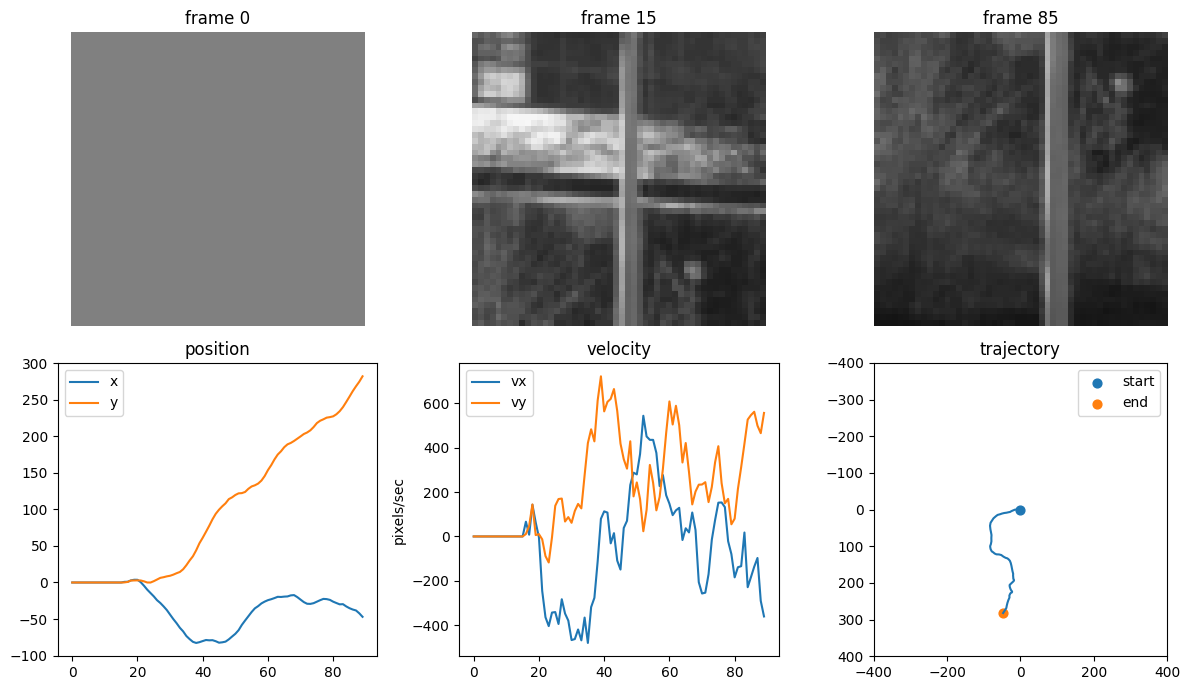

In [102]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [103]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [104]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [105]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt


In [106]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Tiny CNN

In [107]:
class TinyMotionCNN(nn.Module):
    def __init__(self, hidden=16, out_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(1, hidden, kernel_size=(5, 5, 5), padding=(2, 2, 2)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, 2 * hidden, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Conv1d(2 * hidden, 2 * hidden, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.Conv1d(2 * hidden, out_dim, kernel_size=1),
        )

    def forward(self, movie):
        # movie: (B, T, 1, H, W)
        x = movie.permute(0, 2, 1, 3, 4)   # (B, 1, T, H, W)

        z = self.encoder(x)                # (B, F, T, H, W)
        z = z.mean(dim=(-1, -2))           # (B, F, T)

        y = self.decoder(z)                # (B, 2, T)
        y = y.permute(0, 2, 1)             # (B, T, 2)

        return y
    

class TinyMotionCNNInstantDecoder(nn.Module):
    def __init__(self, hidden=16, out_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(1, hidden, kernel_size=(5, 5, 5), padding=(2, 2, 2)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, 2 * hidden, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
        )

        # Instantaneous decoder:
        # z(t) -> velocity(t)
        self.decoder = nn.Linear(2 * hidden, out_dim)

    def forward(self, movie, return_features=False):
        # movie: (B, T, 1, H, W)
        x = movie.permute(0, 2, 1, 3, 4)   # (B, 1, T, H, W)

        z = self.encoder(x)                # (B, F, T, H, W)
        z = z.mean(dim=(-1, -2))           # (B, F, T)

        z_t = z.permute(0, 2, 1)           # (B, T, F)

        y = self.decoder(z_t)              # (B, T, 2)

        if return_features:
            return y, z_t

        return y

class TinyRateMotionCNN(nn.Module):
    def __init__(self, hidden=16, num_neurons=8, out_dim=2, initial_rate=1.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(1, hidden, kernel_size=(5, 5, 5), padding=(2, 2, 2)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, 2 * hidden, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
        )

        self.rate_readout = nn.Linear(2 * hidden, num_neurons)
        self.decoder = nn.Linear(num_neurons, out_dim)

        # Initialize rate bias so softplus(bias) ≈ initial_rate
        bias = torch.log(torch.exp(torch.tensor(float(initial_rate))) - 1.0)
        nn.init.constant_(self.rate_readout.bias, bias)

        # Small decoder initialization
        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.05)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, movie, return_rates=False):
        # movie: (B, T, 1, H, W)
        x = movie.permute(0, 2, 1, 3, 4)   # (B, 1, T, H, W)

        z = self.encoder(x)                # (B, F, T, H, W)
        z = z.mean(dim=(-1, -2))           # (B, F, T)
        z = z.permute(0, 2, 1)             # (B, T, F)

        drive = self.rate_readout(z)       # (B, T, N)
        rates = F.softplus(drive) + 1e-4   # nonnegative rates

        pred = self.decoder(rates)         # (B, T, 2)

        if return_rates:
            return pred, rates

        return pred

## Separable first layer

In [108]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SeparableSTLayer(nn.Module):
    """
    Rank-1 separable spatiotemporal layer.

    movie: (B, T, 1, H, W)

    output: (B, hidden, T, H, W)

    Computation:
        spatial Conv2d per frame
        temporal Conv1d per channel, shared over space
    """

    def __init__(
        self,
        in_channels=1,
        hidden=16,
        spatial_kernel=5,
        temporal_kernel=5,
        spatial_padding=None,
        temporal_causal=False,
    ):
        super().__init__()

        if spatial_padding is None:
            spatial_padding = spatial_kernel // 2

        self.hidden = hidden
        self.temporal_kernel = temporal_kernel
        self.temporal_causal = temporal_causal

        self.spatial_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden,
            kernel_size=spatial_kernel,
            padding=spatial_padding,
            bias=True,
        )

        # groups=hidden means one temporal filter per spatial channel
        self.temporal_conv = nn.Conv1d(
            in_channels=hidden,
            out_channels=hidden,
            kernel_size=temporal_kernel,
            groups=hidden,
            bias=True,
        )

    def forward(self, movie):
        """
        movie: (B, T, 1, H, W)
        returns: (B, hidden, T, H, W)
        """
        B, T, C, H, W = movie.shape

        # Spatial filtering per frame
        x = movie.reshape(B * T, C, H, W)      # (B*T, 1, H, W)
        x = self.spatial_conv(x)               # (B*T, hidden, H, W)

        _, Fch, H1, W1 = x.shape
        x = x.reshape(B, T, Fch, H1, W1)       # (B, T, hidden, H, W)

        # Temporal filtering per channel at each spatial location
        x = x.permute(0, 3, 4, 2, 1)           # (B, H, W, hidden, T)
        x = x.reshape(B * H1 * W1, Fch, T)     # (B*H*W, hidden, T)

        if self.temporal_causal:
            # only past/current frames
            x = F.pad(x, (self.temporal_kernel - 1, 0))
        else:
            # centered/noncausal padding, same length
            left = self.temporal_kernel // 2
            right = self.temporal_kernel - 1 - left
            x = F.pad(x, (left, right))

        x = self.temporal_conv(x)              # (B*H*W, hidden, T)

        # Back to Conv3d format
        x = x.reshape(B, H1, W1, Fch, T)
        x = x.permute(0, 3, 4, 1, 2)           # (B, hidden, T, H, W)

        return x

class TinyRateMotionCNNSeparableFirst(nn.Module):
    def __init__(
        self,
        hidden=16,
        num_neurons=8,
        out_dim=2,
        initial_rate=1.0,
        spatial_kernel_1=5,
        temporal_kernel_1=5,
        temporal_causal=False,
        decoder_init_std=0.05,
    ):
        super().__init__()

        self.st_layer1 = SeparableSTLayer(
            in_channels=1,
            hidden=hidden,
            spatial_kernel=spatial_kernel_1,
            temporal_kernel=temporal_kernel_1,
            temporal_causal=temporal_causal,
        )

        # After separable first layer, keep later layers flexible for now.
        self.encoder_rest = nn.Sequential(
            nn.ReLU(inplace=True),

            nn.Conv3d(
                hidden,
                hidden,
                kernel_size=(5, 3, 3),
                padding=(2, 1, 1),
            ),
            nn.ReLU(inplace=True),

            nn.Conv3d(
                hidden,
                2 * hidden,
                kernel_size=(3, 3, 3),
                padding=(1, 1, 1),
            ),
            nn.ReLU(inplace=True),
        )

        self.rate_readout = nn.Linear(2 * hidden, num_neurons)
        self.decoder = nn.Linear(num_neurons, out_dim)

        # Initialize rate bias so softplus(bias) ≈ initial_rate
        bias = torch.log(torch.exp(torch.tensor(float(initial_rate))) - 1.0)
        nn.init.constant_(self.rate_readout.bias, bias)

        # Decoder initialization
        nn.init.normal_(self.decoder.weight, mean=0.0, std=decoder_init_std)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, movie, return_rates=False):
        """
        movie: (B, T, 1, H, W)
        """
        x = self.st_layer1(movie)          # (B, hidden, T, H, W)
        z = self.encoder_rest(x)          # (B, 2*hidden, T, H, W)

        z = z.mean(dim=(-1, -2))          # (B, 2*hidden, T)
        z = z.permute(0, 2, 1)            # (B, T, 2*hidden)

        drive = self.rate_readout(z)      # (B, T, N)
        rates = F.softplus(drive) + 1e-4

        pred = self.decoder(rates)        # (B, T, 2)

        if return_rates:
            return pred, rates

        return pred

In [109]:
from utilities import compute_velocity_stats, direct_velocity_loss
gray_frames = train_dataset.dataset.gray_frames

vel_mean, vel_std = compute_velocity_stats(
    train_dataset.dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [110]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

# tiny = TinyMotionCNN(hidden=16).to(device)
# tiny = TinyRateMotionCNN(hidden=16).to(device)
tiny = TinyRateMotionCNNSeparableFirst(
    hidden=16,
    num_neurons=8,
    initial_rate=1.0,
    spatial_kernel_1=5,
    temporal_kernel_1=5,
    temporal_causal=True,  # use False first; try True later
    decoder_init_std=0.05,
).to(device)

optimizer = torch.optim.AdamW(tiny.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(300):
    pred = tiny(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(tiny.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 0.8415908813476562
25 0.8181575536727905
50 0.8160862326622009
75 0.8098244667053223
100 0.7973124384880066
125 0.779582142829895
150 0.7260567545890808
175 0.7007014155387878
200 0.5724761486053467
225 0.5065881013870239
250 0.46845540404319763
275 0.4142819941043854


## Train tiny CNN in whole dataset

In [111]:
print("train batches per epoch:", len(train_loader))
print("val batches per epoch:", len(val_loader))
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

train batches per epoch: 98
val batches per epoch: 25
train samples: 1560
val samples: 390


In [113]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# tiny = TinyRateMotionCNN(hidden=16).to(device)

tiny = TinyRateMotionCNNSeparableFirst(
    hidden=16,
    num_neurons=8,
    initial_rate=1.0,
    spatial_kernel_1=5,
    temporal_kernel_1=5,
    temporal_causal=True,  # use False first; try True later
    decoder_init_std=0.05,
).to(device)


optimizer = torch.optim.AdamW(
    tiny.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred = model(movie)

        loss = direct_velocity_loss(
            pred_vel_z=pred,
            target_vel=target,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        tiny,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            tiny,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | train 1.0017 | val 0.9659


Tiny instant epoch 002 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 002 val:   0%|          | 0/25 [00:00<?, ?it/s]

...

Tiny instant epoch 029 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 029 | train 0.0487 | val 0.0458


Tiny instant epoch 030 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 030 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 030 | train 0.0472 | val 0.0557


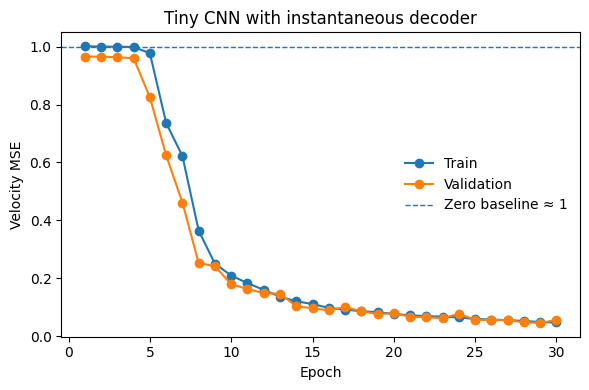

In [114]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Tiny CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [115]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    vel_mean,
    vel_std,
    gray_frames,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)  # raw px/s, (B, T, 2)

        pred_z = model(movie)                   # normalized, (B, T, 2)
        pred = pred_z * vel_std + vel_mean      # back to px/s

        pred = pred[:, gray_frames:, :]
        target = target[:, gray_frames:, :]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=tiny,
    val_loader=val_loader,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.9255064
SEM R²: 0.0033118345171159087
N validation movies: 390
Min/Max R²: 0.38981384 0.9861143


/tmp/ipykernel_32604/2314121497.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


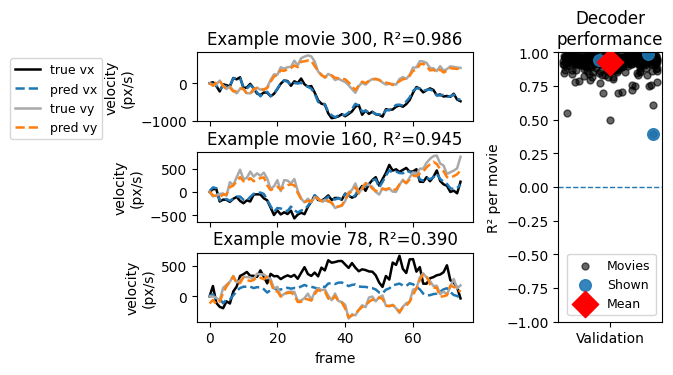

In [116]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Example movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(-1, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)

In [120]:
@torch.no_grad()
def rate_velocity_correlations(model, loader, gray_frames, device):
    model.eval()

    all_rates = []
    all_vel = []

    for batch in loader:
        movie = batch["movie"].to(device)
        vel = batch["scene_vel"].to(device)

        pred, rates = model(movie, return_rates=True)

        rates = rates[:, gray_frames:, :]  # (B,T,N)
        vel = vel[:, gray_frames:, :]      # (B,T,2)

        all_rates.append(rates.reshape(-1, rates.shape[-1]).cpu())
        all_vel.append(vel.reshape(-1, 2).cpu())

    R = torch.cat(all_rates, dim=0)  # (samples, N)
    V = torch.cat(all_vel, dim=0)    # (samples, 2)

    R = R - R.mean(dim=0, keepdim=True)
    V = V - V.mean(dim=0, keepdim=True)

    corr = (R.T @ V) / (
        torch.sqrt((R**2).sum(dim=0, keepdim=True)).T
        * torch.sqrt((V**2).sum(dim=0, keepdim=True))
        + 1e-8
    )

    return corr.numpy()

corr = rate_velocity_correlations(
    tiny,
    val_loader,
    gray_frames=gray_frames,
    device=device,
)
print("[neuron, (vx, vy)] correlations:")
print(corr)  # shape (num_neurons, 2)

[neuron, (vx, vy)] correlations:
[[ 0.06362174 -0.651733  ]
 [ 0.05542233  0.60265905]
 [-0.8627333  -0.3144254 ]
 [ 0.2972046  -0.8625062 ]
 [-0.00598818  0.93266237]
 [ 0.6597563   0.5495598 ]
 [ 0.83551913 -0.16532347]
 [-0.8048711   0.2133729 ]]


In [121]:
corr = rate_velocity_correlations(tiny, val_loader, gray_frames, device)

pref_angle = np.arctan2(corr[:, 1], corr[:, 0])
pref_strength = np.linalg.norm(corr, axis=1)

for i, (ang, strength) in enumerate(zip(pref_angle, pref_strength)):
    print(
        f"unit {i:02d}: angle={np.degrees(ang):7.1f} deg, "
        f"strength={strength:.3f}, corr_vx={corr[i,0]:.3f}, corr_vy={corr[i,1]:.3f}"
    )

unit 00: angle=  -84.4 deg, strength=0.655, corr_vx=0.064, corr_vy=-0.652
unit 01: angle=   84.7 deg, strength=0.605, corr_vx=0.055, corr_vy=0.603
unit 02: angle= -160.0 deg, strength=0.918, corr_vx=-0.863, corr_vy=-0.314
unit 03: angle=  -71.0 deg, strength=0.912, corr_vx=0.297, corr_vy=-0.863
unit 04: angle=   90.4 deg, strength=0.933, corr_vx=-0.006, corr_vy=0.933
unit 05: angle=   39.8 deg, strength=0.859, corr_vx=0.660, corr_vy=0.550
unit 06: angle=  -11.2 deg, strength=0.852, corr_vx=0.836, corr_vy=-0.165
unit 07: angle=  165.2 deg, strength=0.833, corr_vx=-0.805, corr_vy=0.213


torch.Size([16, 1, 5, 5])
torch.Size([16, 1, 5])


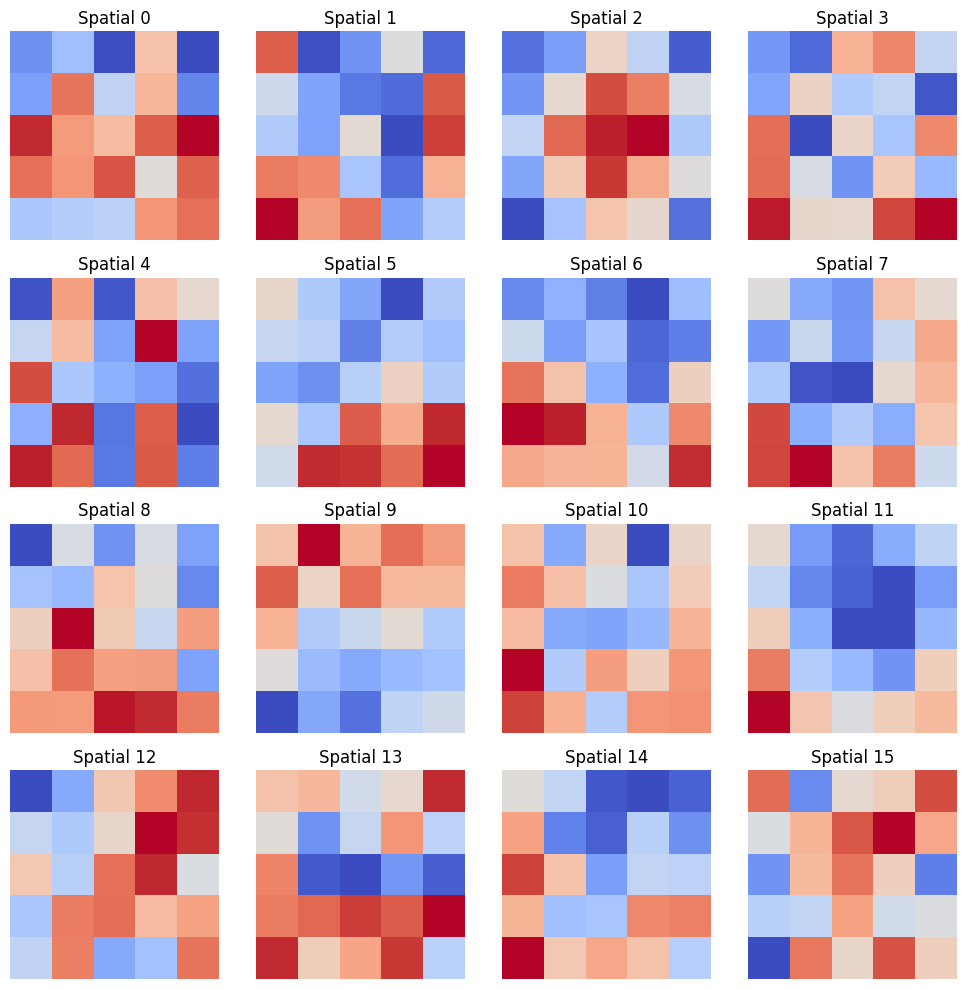

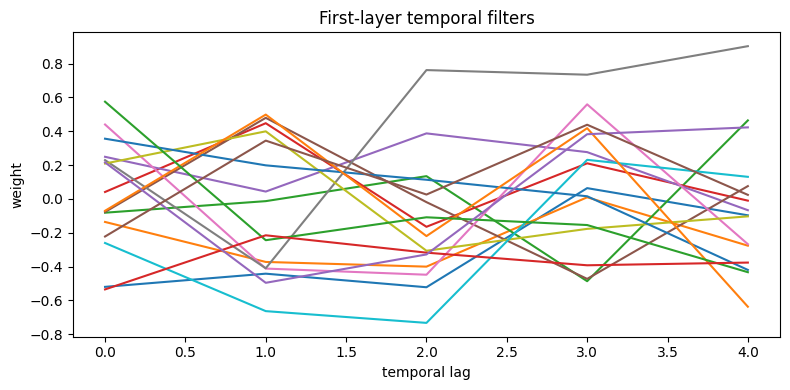

In [125]:
W_spatial = tiny.st_layer1.spatial_conv.weight.detach().cpu()
print(W_spatial.shape)  # (hidden, 1, kH, kW)

W_temporal = tiny.st_layer1.temporal_conv.weight.detach().cpu()
print(W_temporal.shape)  # (hidden, 1, kT), because groups=hidden

import matplotlib.pyplot as plt

def plot_separable_first_layer_filters(model, n_cols=4):
    W_spatial = model.st_layer1.spatial_conv.weight.detach().cpu().numpy()
    W_temporal = model.st_layer1.temporal_conv.weight.detach().cpu().numpy()

    hidden = W_spatial.shape[0]
    n_rows = int(np.ceil(hidden / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 2.5*n_rows))
    axs = np.asarray(axs).reshape(-1)

    for i in range(hidden):
        ax = axs[i]
        ax.imshow(W_spatial[i, 0], cmap="coolwarm")
        ax.set_title(f"Spatial {i}")
        ax.axis("off")

    for j in range(hidden, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    for i in range(hidden):
        plt.plot(W_temporal[i, 0], label=f"{i}")
    plt.xlabel("temporal lag")
    plt.ylabel("weight")
    plt.title("First-layer temporal filters")
    plt.tight_layout()
    plt.show()

plot_separable_first_layer_filters(tiny, n_cols=4)